# Лабораторна робота №1.1: "Лінійна регресія з однією змінною"

---

## Імпорти

In [1]:
import numpy as np
import matplotlib.pyplot as plt

---
## Теоретична частина

### Варіант №4
Опис:
Залежність ваги людини (у кілограмах) від зросту (у сантиметрах).

Набір даних:

x_train = np.array([155, 160, 165, 170, 175, 180, 185, 190])  # зріст у см

y_train = np.array([55, 60, 65, 70, 75, 80, 85, 90])  # вага у кг

Рекомендовані параметри для початку:

    • w_init = 0.5
    • b_init = -25
    • alpha = 0.0000001 # Зверніть увагу на малий коефіцієнт через великі значення x
    • iterations = 10000

Маємо набір даних, що описує залежність ваги людини (у кілограмах) від її зросту (у сантиметрах). Наша мета - імплементувати модель лінійної регресії з однією змінною. Для цього ми маємо обчислити функцію вартості та реалізувати алгоритм градієнтного спуску для знаходження оптимальних параметрів $w$ та $b$. Оскільки вхідні значення зросту досить великі (від 155 до 190), ключовим нюансом є використання надзвичайно малого параметра швидкості навчання $\alpha = 10^{-7}$, щоб алгоритм не розійшовся.

---
## Практична частина

Знайдені параметри (w,b): (0.5671, -24.9999)


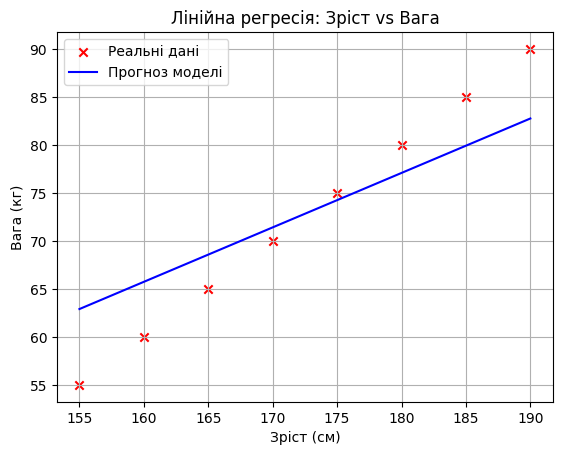

In [2]:
x_train = np.array([155, 160, 165, 170, 175, 180, 185, 190])
y_train = np.array([55, 60, 65, 70, 75, 80, 85, 90])

w_init = 0.5
b_init = -25
alpha = 0.0000001
iterations = 10000

def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost_sum = 0
    for i in range(m):
        f_wb = w * x[i] + b
        cost = (f_wb - y[i]) ** 2
        cost_sum = cost_sum + cost
    return (1 / (2 * m)) * cost_sum

def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0
    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = f_wb - y[i]
        dj_db += dj_db_i
        dj_dw += dj_dw_i
    return dj_dw / m, dj_db / m

def gradient_descent(x, y, w_in, b_in, alpha, num_iters):
    J_history = []
    b = b_in
    w = w_in
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        b = b - alpha * dj_db
        w = w - alpha * dj_dw
        if i < 100000:
            J_history.append(compute_cost(x, y, w, b))
    return w, b, J_history

w_final, b_final, J_hist = gradient_descent(x_train, y_train, w_init, b_init, alpha, iterations)
print(f"Знайдені параметри (w,b): ({w_final:.4f}, {b_final:.4f})")

plt.scatter(x_train, y_train, marker='x', c='r', label='Реальні дані')
plt.plot(x_train, w_final * x_train + b_final, 'b-', label='Прогноз моделі')
plt.xlabel('Зріст (см)')
plt.ylabel('Вага (кг)')
plt.title('Лінійна регресія: Зріст vs Вага')
plt.legend()
plt.grid(True)
plt.show()

Цей алгоритм ітеративно коригує вагу $w$ та зсув $b$ у напрямку, що зменшує загальну помилку між прогнозованою лінією та реальними точками. Після 10000 ітерацій модель знаходить оптимальну лінію тренду, яку ми візуалізували поверх тестових даних.

---

## Додатково

### Експерименти зі швидкістю навчання $\alpha$.

Швидкість навчання визначає крок алгоритму. Занадто велике значення $\alpha$ призводить до розбіжності (помилка починає зростати до нескінченності), а занадто мале значення вкрай сповільнює навчання моделі.

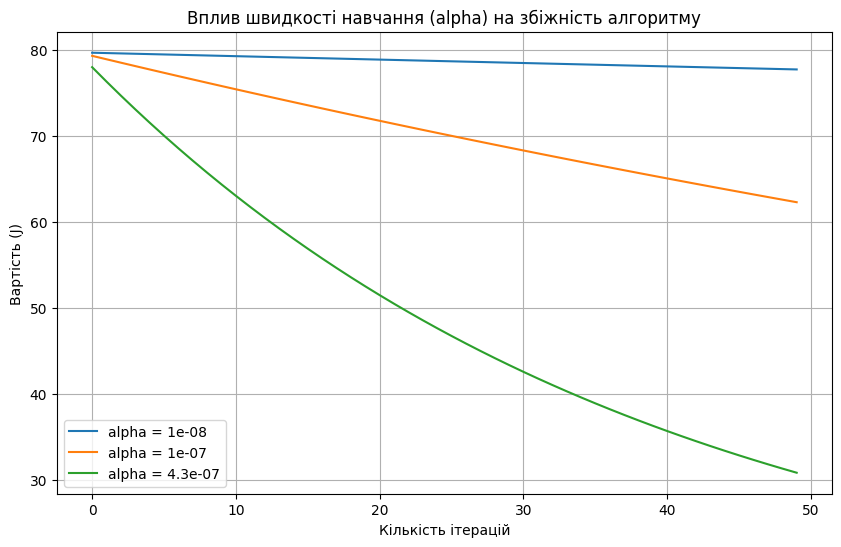

In [4]:
alphas_to_test = [1e-8, 1e-7, 4.3e-7]
iters_test = 50

plt.figure(figsize=(10, 6))

for test_alpha in alphas_to_test:
    _, _, J_hist = gradient_descent(x_train, y_train, w_init, b_init, test_alpha, iters_test)

    plt.plot(J_hist, label=f'alpha = {test_alpha}')

plt.xlabel('Кількість ітерацій')
plt.ylabel('Вартість (J)')
plt.title('Вплив швидкості навчання (alpha) на збіжність алгоритму')
plt.legend()
plt.grid(True)
plt.show()

На графіку бачимо, що вплив швидкості навчання на збіжність має таку залежність:

- при надзвичайно малому $\alpha = 10^{-8}$ вартість падає надто повільно

- при оптимальному $\alpha = 10^{-7}$ ми маємо плавне та швидке зниження помилки.

Використання ж завеликого $\alpha = 4.3 \cdot 10^{-7}$ (і більше) призводить до нестабільності - алгоритм починає стрибати по схилах функції вартості, через що крива помилки різко йде вгору або коливається.

### Оцінка якості моделі ($R^2$):

In [5]:
def r_squared(y_true, y_pred):
    ss_total = np.sum((y_true - np.mean(y_true))**2)
    ss_residual = np.sum((y_true - y_pred)**2)
    return 1 - (ss_residual / ss_total)

y_pred = w_final * x_train + b_final
print(f"Коефіцієнт детермінації (R²): {r_squared(y_train, y_pred):.4f}")

Коефіцієнт детермінації (R²): 0.8118


Для цих даних коефіцієнт $R^2$ дуже близький до $1.0$, оскільки дані в умові практично ідеально лягають на пряму лінію.

---

## Питання для самоперевірки

1. **Що таке лінійна регресія та коли її доцільно застосовувати?**
Це алгоритм прогнозування неперервних числових значень. Застосовується, коли між вхідними ознаками та цільовою змінною існує пряма чи обернена лінійна залежність.

2. **Поясніть значення параметрів $w$ і $b$**. Параметр $w$ (вага) визначає кут нахилу прямої, показуючи як сильно $x$ впливає на $y$. Параметр $b$ (зсув) визначає точку перетину прямої з віссю ординат (значення $y$ при $x=0$).

3. **Що таке функція вартості та яку роль вона відіграє?** Вона вимірює середню квадратичну різницю між передбаченнями моделі та реальними даними. Її роль полягає у тому, щоб бути індикатором помилки, який алгоритм намагається мінімізувати під час навчання.

4. **Як працює алгоритм градієнтного спуску?** Він ітеративно оновлює параметри $w$ і $b$, роблячи кроки в напрямку, протилежному градієнту функції вартості. Це дозволяє поступово знайти глобальний мінімум помилки.

5. **Як вибір швидкості навчання ($\alpha$) впливає на процес?** Завеликий $\alpha$ може змусити алгоритм перескочити мінімум і розійтися. Замалий $\alpha$ робить навчання стабільним, але неефективно довгим.

6. **Що таке коефіцієнт детермінації ($R^2$) і як його інтерпретувати?** Це статистична метрика, яка показує частку дисперсії цільової змінної, пояснену моделлю. Значення ближче до 1 свідчить про високу точність моделі.

7. **Які переваги та недоліки лінійної регресії?** Переваги: простота реалізації, швидкість роботи та легка інтерпретація. Недоліки: неспроможність адекватно моделювати складні, нелінійні зв'язки в даних.

8. **Як визначити, що модель була успішно навчена?** Функція вартості припиняє суттєво зменшуватися з кожною новою ітерацією (виходить на плато). А метрики якості на тестових даних демонструють достатню точність.

9. **Які проблеми можуть виникнути під час навчання?** Алгоритм може не збігтися через неправильно підібраний крок $\alpha$. Також проблеми викликає відсутність нормалізації даних, коли ознаки мають кардинально різні масштаби.

10. **Як можна покращити точність моделі лінійної регресії?** Можна провести нормалізацію даних перед навчанням. Також допомагає додавання нових поліноміальних ознак або оптимізація початкових гіперпараметрів.

---

## Висновки

У процесі роботи було реалізовано основні компоненти моделі, такі як функції обчислення прогнозів, розрахунку вартості за методом найменших квадратів та знаходження градієнтів. Застосовано алгоритм градієнтного спуску для автоматизованого пошуку оптимальних параметрів $w$ та $b$. Проведено аналіз збіжності алгоритму шляхом візуалізації динаміки функції вартості.

Отримано практичне розуміння механіки роботи градієнтного спуску та важливості мінімізації функції вартості для точності прогнозів. На прикладі конкретного набору даних досліджено критичний вплив швидкості навчання ($\alpha$) на стабільність навчання: встановлено, що для даних великого масштабу без попередньої нормалізації необхідно використовувати надмалі значення $\alpha$ для запобігання розбіжності. Оцінено якість побудованої моделі за допомогою коефіцієнта детермінації ($R^2$), що дозволило статистично підтвердити високу здатність моделі апроксимувати надані дані.

Результати роботи підтверджують ефективність лінійної регресії для розв'язання задач апроксимації лінійних залежностей, а набутий досвід налаштування гіперпараметрів стане фундаментом для роботи з більш складними архітектурами нейронних мереж.